In [ ]:
import numpy as np
import torch
from BIEO import util, objective, solve_sa_discrete

torch.cuda.is_available()

True

In [ ]:
DEVICE = 'cuda'

result_domain = 'path to your data /predictions/jrc_mus-liver.zarr/'
origin_domain = 'path to your original data'
class_names = ['cyto', 'endo_lum', 'endo_mem', 'ecs', 'pm', 'bg']
label_names = ['cyto', 'endo_lum', 'endo_mem', 'ecs', 'pm', 'other']


logits = util.load_multiclass_result(class_names, result_domain, crop='crop144', scale='s0')
logits = np.expand_dims(logits, axis=0)
logits = torch.tensor(logits, device=DEVICE)

logits.shape

torch.Size([1, 100, 100, 100, 6])

In [3]:
forbidden_adjacency_pairs = [
    (1, 0),  # 囊泡质和细胞质
    (1, 5),  # 囊泡质和其他结构
    (1, 3),  # 囊泡质和胞外空间

    (2, 5),  # 囊泡膜和其他结构

    (4, 1),  # 细胞膜和囊泡质
    (4, 2),  # 细胞膜和囊泡膜
    (4, 5),  # 细胞膜和其他结构

    (0, 3),  # 细胞质和胞外
    (2, 3),  # 囊泡膜和胞外
    (3, 5),  # 其他结构和胞外
]

forbidden_enclosure_pair = [
    # (inner, outer)
    (4, 0),  # 细胞膜-细胞质
    (4, 2),  # 细胞膜-囊泡膜
    (2, 1),  # 囊泡膜-囊泡质
    # (3, 4)
]

In [4]:
em_crop = util.load_em_crop(origin_domain, dataset='jrc_mus-liver', crop='crop144', scale='s0')
em_crop, em_crop.shape

(array([[[119., 129., 127., ..., 100.,  92.,  96.],
         [120., 133., 129., ..., 109., 101., 105.],
         [119., 137., 138., ..., 120., 119., 128.],
         ...,
         [122., 124., 121., ..., 187., 190., 183.],
         [119., 111., 101., ..., 183., 183., 182.],
         [116., 112., 100., ..., 184., 183., 182.]],
 
        [[116., 130., 132., ..., 108.,  99., 108.],
         [121., 129., 136., ..., 117., 110., 122.],
         [125., 135., 125., ..., 132., 123., 128.],
         ...,
         [134., 138., 133., ..., 187., 187., 186.],
         [122., 124., 120., ..., 181., 186., 184.],
         [119., 125., 115., ..., 181., 187., 181.]],
 
        [[121., 124., 130., ..., 106., 116., 119.],
         [127., 129., 135., ..., 115., 121., 133.],
         [130., 141., 136., ..., 134., 133., 130.],
         ...,
         [140., 133., 135., ..., 192., 183., 179.],
         [135., 133., 132., ..., 188., 189., 181.],
         [135., 136., 129., ..., 185., 180., 188.]],
 
        ...,


In [ ]:
bg_data_domain = 'path to your background data'

bg_labels = util.load_groundtruth(bg_data_domain, 'jrc_mus-liver', crop='crop144', class_name='bg', scale='s1')
other_labels = util.load_multiclass_groundtruth(class_names[:-1], origin_domain, 'jrc_mus-liver', crop='crop144', scale='s1')

groundtruth_labels = np.concat([other_labels, np.expand_dims(bg_labels, axis=-1)], axis=-1)
groundtruth_labels.shape

(100, 100, 100, 6)

In [6]:
C_unary = -logits.log_softmax(dim=-1)

C_smooth = objective.smoothness_penalty(len(class_names), weight=10000, device=DEVICE)
C_adjacency = objective.forbidden_adjacency_penalty(
    len(class_names),
    forbidden_adjacency_pairs,
    weight=5000000, device=DEVICE)
C_adj = objective.combine_adj_costs(C_smooth, C_adjacency)

C_unary.shape, C_smooth.shape, C_adjacency.shape, C_adj.shape

(torch.Size([1, 100, 100, 100, 6]),
 torch.Size([6, 6]),
 torch.Size([6, 6]),
 torch.Size([6, 6]))

In [7]:
best_logits = solve_sa_discrete.solve_sa(
    C_unary,
    C_adj,

    # step_init=(logits.max() - logits.min()) * 0.15,
    X_init=logits,

    # T_init=5e-2,
    T_final=1e-3,
    n_iter=300,
    C_enclose=1e6,
    forbidden_enclosure_pairs=forbidden_enclosure_pair,
)

Iter 0 | Cost: [[205975486464.0]]
Iter 1 | Cost: [[151700865024.0]]
Iter 2 | Cost: [[116177436672.0]]
Iter 3 | Cost: [[92104835072.0]]
Iter 4 | Cost: [[73780387840.0]]
Iter 5 | Cost: [[59757920256.0]]
Iter 6 | Cost: [[48378658816.0]]
Iter 7 | Cost: [[39528411136.0]]
Iter 8 | Cost: [[32389758976.0]]
Iter 9 | Cost: [[27104854016.0]]
Iter 10 | Cost: [[23097401344.0]]
Iter 11 | Cost: [[19915894784.0]]
Iter 12 | Cost: [[17531588608.0]]
Iter 13 | Cost: [[15670861824.0]]
Iter 14 | Cost: [[14086430720.0]]
Iter 15 | Cost: [[12894124032.0]]
Iter 16 | Cost: [[11998465024.0]]
Iter 17 | Cost: [[11158358016.0]]
Iter 18 | Cost: [[10535727104.0]]
Iter 19 | Cost: [[9982666752.0]]
Iter 20 | Cost: [[9530857472.0]]
Iter 21 | Cost: [[9126896640.0]]
Iter 22 | Cost: [[8784629760.0]]
Iter 23 | Cost: [[8513008640.0]]
Iter 24 | Cost: [[8232957440.0]]
Iter 25 | Cost: [[7992726528.0]]
Iter 26 | Cost: [[7814136832.0]]
Iter 27 | Cost: [[7585757184.0]]
Iter 28 | Cost: [[7349997056.0]]
Iter 29 | Cost: [[7175536640.0]

In [ ]:
from BIEO.repair import probability_dilation

dilated_labels = probability_dilation(
    X=best_logits.argmax(dim=-1),
    logits=logits,
    forbidden_enclosure_pairs=forbidden_enclosure_pair,
    min_inner_neighbors=4,
    threshold=0.71
)

probability_dilation: inner=4 outer=0 round 1, flipped 580 voxels
probability_dilation: inner=4 outer=0 round 2, flipped 607 voxels
probability_dilation: inner=4 outer=0 round 3, flipped 442 voxels
probability_dilation: inner=4 outer=0 round 4, flipped 162 voxels
probability_dilation: inner=4 outer=0 round 5, flipped 34 voxels
probability_dilation: inner=4 outer=0 round 6, flipped 2 voxels
probability_dilation: inner=2 outer=1 round 1, flipped 1426 voxels
probability_dilation: inner=2 outer=1 round 2, flipped 927 voxels
probability_dilation: inner=2 outer=1 round 3, flipped 403 voxels
probability_dilation: inner=2 outer=1 round 4, flipped 219 voxels
probability_dilation: inner=2 outer=1 round 5, flipped 122 voxels
probability_dilation: inner=2 outer=1 round 6, flipped 70 voxels
probability_dilation: inner=2 outer=1 round 7, flipped 34 voxels
probability_dilation: inner=2 outer=1 round 8, flipped 24 voxels
probability_dilation: inner=2 outer=1 round 9, flipped 18 voxels
probability_dila

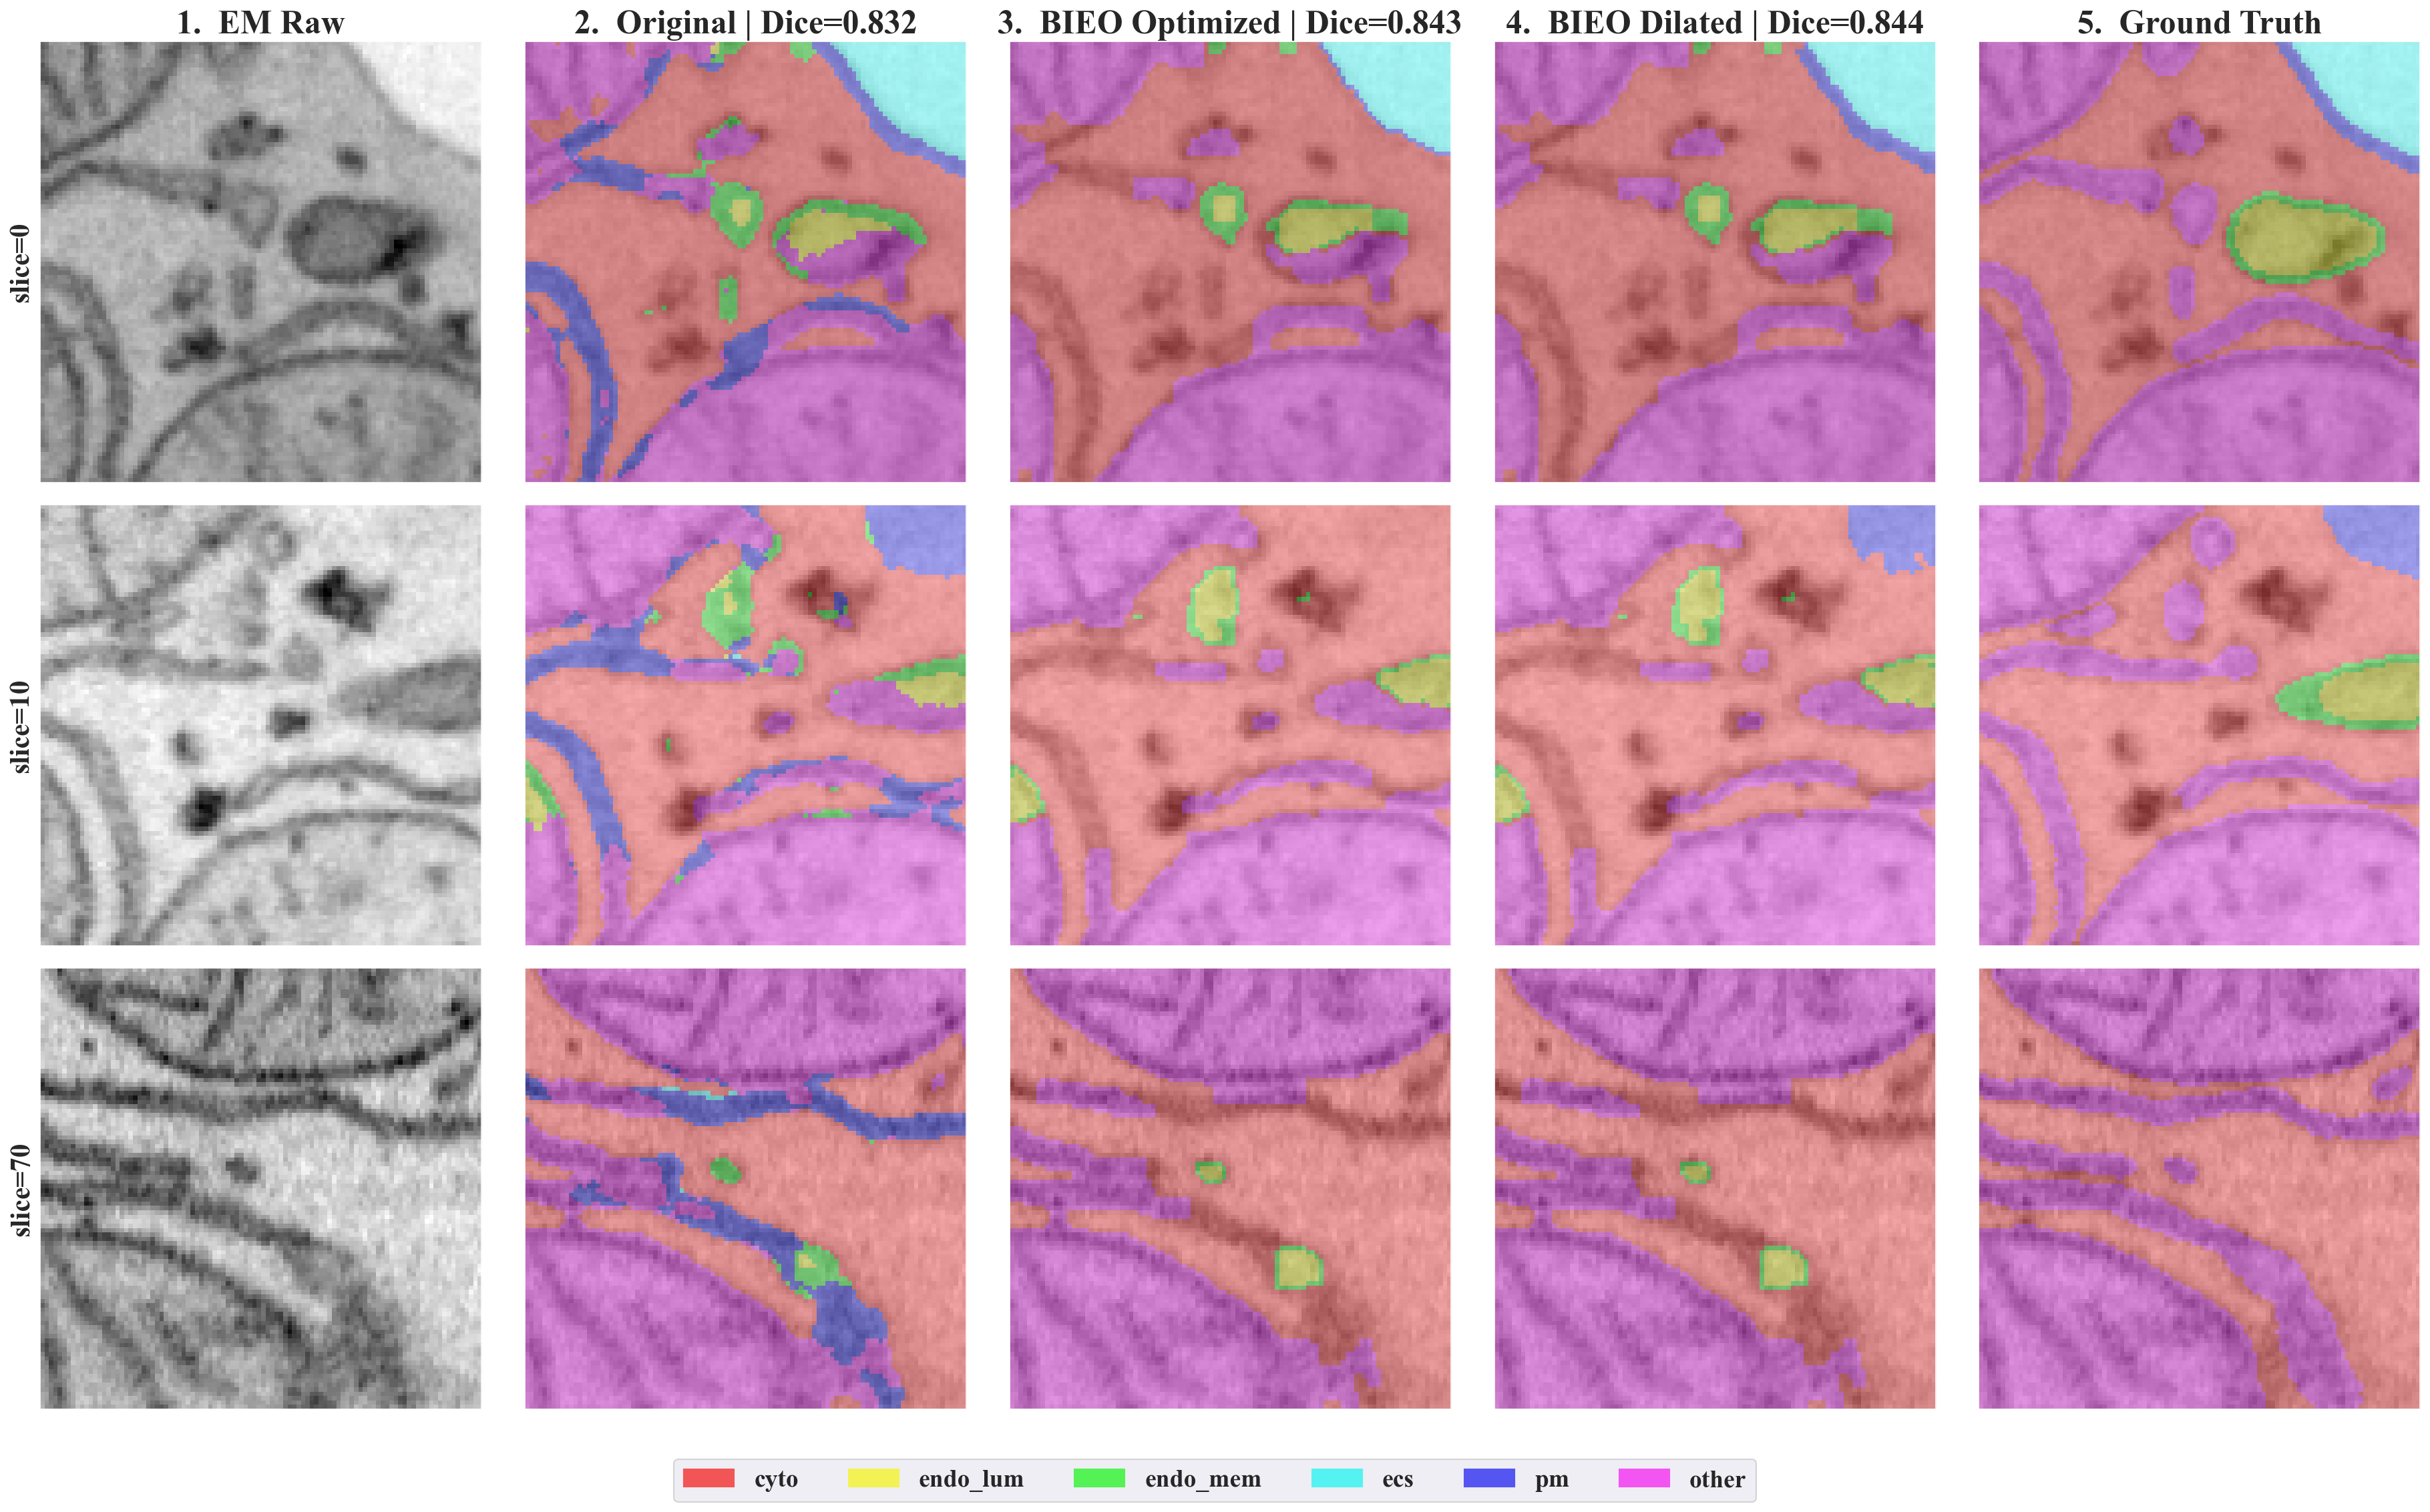

In [17]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams.update({
    'font.size': 20,
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.weight': 'bold',
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
})

j_values = [0, 10, 70]
col_titles = [
    '1.  EM Raw',
    '2.  Original | Dice=0.832',
    '3.  BIEO Optimized | Dice=0.843',
    '4.  BIEO Dilated | Dice=0.844',
    '5.  Ground Truth'
]

fig, axes = plt.subplots(3, 5, figsize=(25, 15), dpi=150)

for row, j in enumerate(j_values):
    em_slice = em_crop[j]
    em_gray = (em_slice - em_slice.min()) / (em_slice.max() - em_slice.min() + 1e-8)
    axes[row, 0].imshow(em_gray.T, cmap='gray', origin='lower')
    if row == 0:
        axes[row, 0].set_title(col_titles[0])

    util.visualize(
        torch.tensor(em_crop[j]),
        logits.argmax(dim=-1)[0, j],
        label_names=class_names,
        ax=axes[row, 1],
        title=col_titles[1] if row == 0 else None,
        legend=False,
    )

    util.visualize(
        torch.tensor(em_crop[j]),
        best_logits.argmax(dim=-1)[0, j],
        label_names=label_names,
        ax=axes[row, 2],
        title=col_titles[2] if row == 0 else None,
        legend=False,
    )

    util.visualize(
        torch.tensor(em_crop[j]),
        dilated_labels[0, j],
        label_names=label_names,
        ax=axes[row, 3],
        title=col_titles[3] if row == 0 else None,
        legend=False,
    )

    util.visualize(
        torch.tensor(em_crop[j]),
        torch.tensor(groundtruth_labels.argmax(axis=-1))[j],
        label_names=label_names,
        ax=axes[row, 4],
        title=col_titles[4] if row == 0 else None,
        legend=False,
    )

    axes[row, 0].set_ylabel(f'slice={j}', fontsize=20)

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

class_colors = util.get_class_colors(label_names)
handles = [Patch(color=color, label=name) for name, color in class_colors.items()]
fig.legend(handles=handles, loc='lower center', ncol=len(label_names), bbox_to_anchor=(0.5, -0.02), fontsize=18)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.subplots_adjust(wspace=0.02, hspace=0.05)
plt.savefig('./fig.png', dpi=300, bbox_inches='tight')

In [ ]:
from torchmetrics import F1Score
from BIEO.evaluate import compute_iou

In [11]:
(
    compute_iou(logits.argmax(dim=-1).squeeze().cpu(), groundtruth_labels.argmax(axis=-1), class_names),
    compute_iou(best_logits.argmax(dim=-1).squeeze().cpu(), groundtruth_labels.argmax(axis=-1), class_names),
    compute_iou(dilated_labels.squeeze().cpu(), groundtruth_labels.argmax(axis=-1), class_names),
)

({'cyto': 0.879323422908783,
  'endo_lum': 0.13726766407489777,
  'endo_mem': 0.022929901257157326,
  'ecs': 0.717583179473877,
  'pm': 0.026443924754858017,
  'bg': 0.748254120349884,
  'mean_iou': 0.4219670354699095},
 {'cyto': 0.7656471133232117,
  'endo_lum': 0.08330637216567993,
  'endo_mem': 0.027476757764816284,
  'ecs': 0.8965814709663391,
  'pm': 0.17214836180210114,
  'bg': 0.7554128766059875,
  'mean_iou': 0.4500954921046893},
 {'cyto': 0.7680113911628723,
  'endo_lum': 0.09135882556438446,
  'endo_mem': 0.025225941091775894,
  'ecs': 0.8965814709663391,
  'pm': 0.7425109148025513,
  'bg': 0.7554128766059875,
  'mean_iou': 0.5465169033656517})

In [12]:
f1_score = F1Score('multiclass', num_classes=len(class_names))

(
    f1_score(logits.argmax(dim=-1).squeeze().cpu(), torch.tensor(groundtruth_labels.argmax(axis=-1))),
    f1_score(best_logits.argmax(dim=-1).squeeze().cpu(), torch.tensor(groundtruth_labels.argmax(axis=-1))),
    f1_score(dilated_labels.squeeze().cpu(), torch.tensor(groundtruth_labels.argmax(axis=-1))),
)

(tensor(0.8320), tensor(0.8429), tensor(0.8446))

In [13]:
logits.argmax(dim=-1).unsqueeze(dim=0).shape, groundtruth_labels.argmax(axis=-1).shape

(torch.Size([1, 1, 100, 100, 100]), (100, 100, 100))

In [14]:
# 计算accuracy
(logits.argmax(dim=-1).unsqueeze(dim=0).cpu().numpy() == groundtruth_labels.argmax(axis=-1)).mean()

np.float64(0.831979)

In [15]:
# 计算accuracy
(best_logits.argmax(dim=-1).unsqueeze(dim=0).cpu().numpy() == groundtruth_labels.argmax(axis=-1)).mean()

np.float64(0.842946)

In [16]:
# 计算accuracy
(dilated_labels.unsqueeze(dim=0).cpu().numpy() == groundtruth_labels.argmax(axis=-1)).mean()

np.float64(0.844566)